Date Submitted: 07/04/25

# Student Performance Dataset
- Goal: Predict the Final Year Grade (G3)
- 30 Features
- Initially thought out to be a classification problem, but adjusted for regression
- Reason for this is explained later
- Methods Implemented:
  - K Nearest Neighbours (Classifier, first)
  - K Nearest Neighbours (Regressor, adjustment)
  - Decision Tree Regressor
  - Neural Network (MLPRegressor)
  - Linear Regression (Ordinary Least Squares)
  - Linear Regression Reduced (Dropped G1 and G2 from X)

https://archive.ics.uci.edu/dataset/320/student+performance

Evaluation Results of Each Method

| Algorithm                    | Train R² Score | Test R² Score |
|-----------------------------|----------------|----------------|
| KNN (Classifier)            | 0.46 (Train Score)|0.35 (Test Score)                |
| KNN (Regressor)             | 0.86           | 0.83           |
| Decision Tree (Regressor)   | 0.98           | 0.88           |
| Neural Network (MLPRegressor)| 1.00           | 0.86           |
| Linear Regression (OLS)     | 0.86           | 0.79           |
| Linear Regression (Reduced) | 0.26           | 0.13           |

---

### Data Loading & Preprocessing

In [ ]:
# Using Colab, so can load use Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/student-mat.csv')

In [ ]:
data = pd.DataFrame(data)

In [ ]:
data.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [ ]:
data.shape

(395, 33)

In [ ]:
# Check for missing data
data.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


Can see from data.info() that some Dtypes are not of float64 or int64

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [ ]:
data.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [ ]:
# Print column names of Dtype object
for column in data.columns:
  if data[column].dtype == 'object':
    print(column)

school
sex
address
famsize
Pstatus
Mjob
Fjob
reason
guardian
schoolsup
famsup
paid
activities
nursery
higher
internet
romantic


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [ ]:
# Convert non-numerical values to numerical values
for column in data.columns:
  if data[column].dtype == 'object':
    data[column] = le.fit_transform(data[column])

In [ ]:
data.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,0,0,18,1,0,0,4,4,0,4,...,4,3,4,1,1,3,6,5,6,6
1,0,0,17,1,0,1,1,1,0,2,...,5,3,3,1,1,3,4,5,5,6
2,0,0,15,1,1,1,1,1,0,2,...,4,3,2,2,3,3,10,7,8,10
3,0,0,15,1,0,1,4,2,1,3,...,3,2,2,1,1,5,2,15,14,15
4,0,0,16,1,0,1,3,3,2,2,...,4,3,2,1,2,5,4,6,10,10


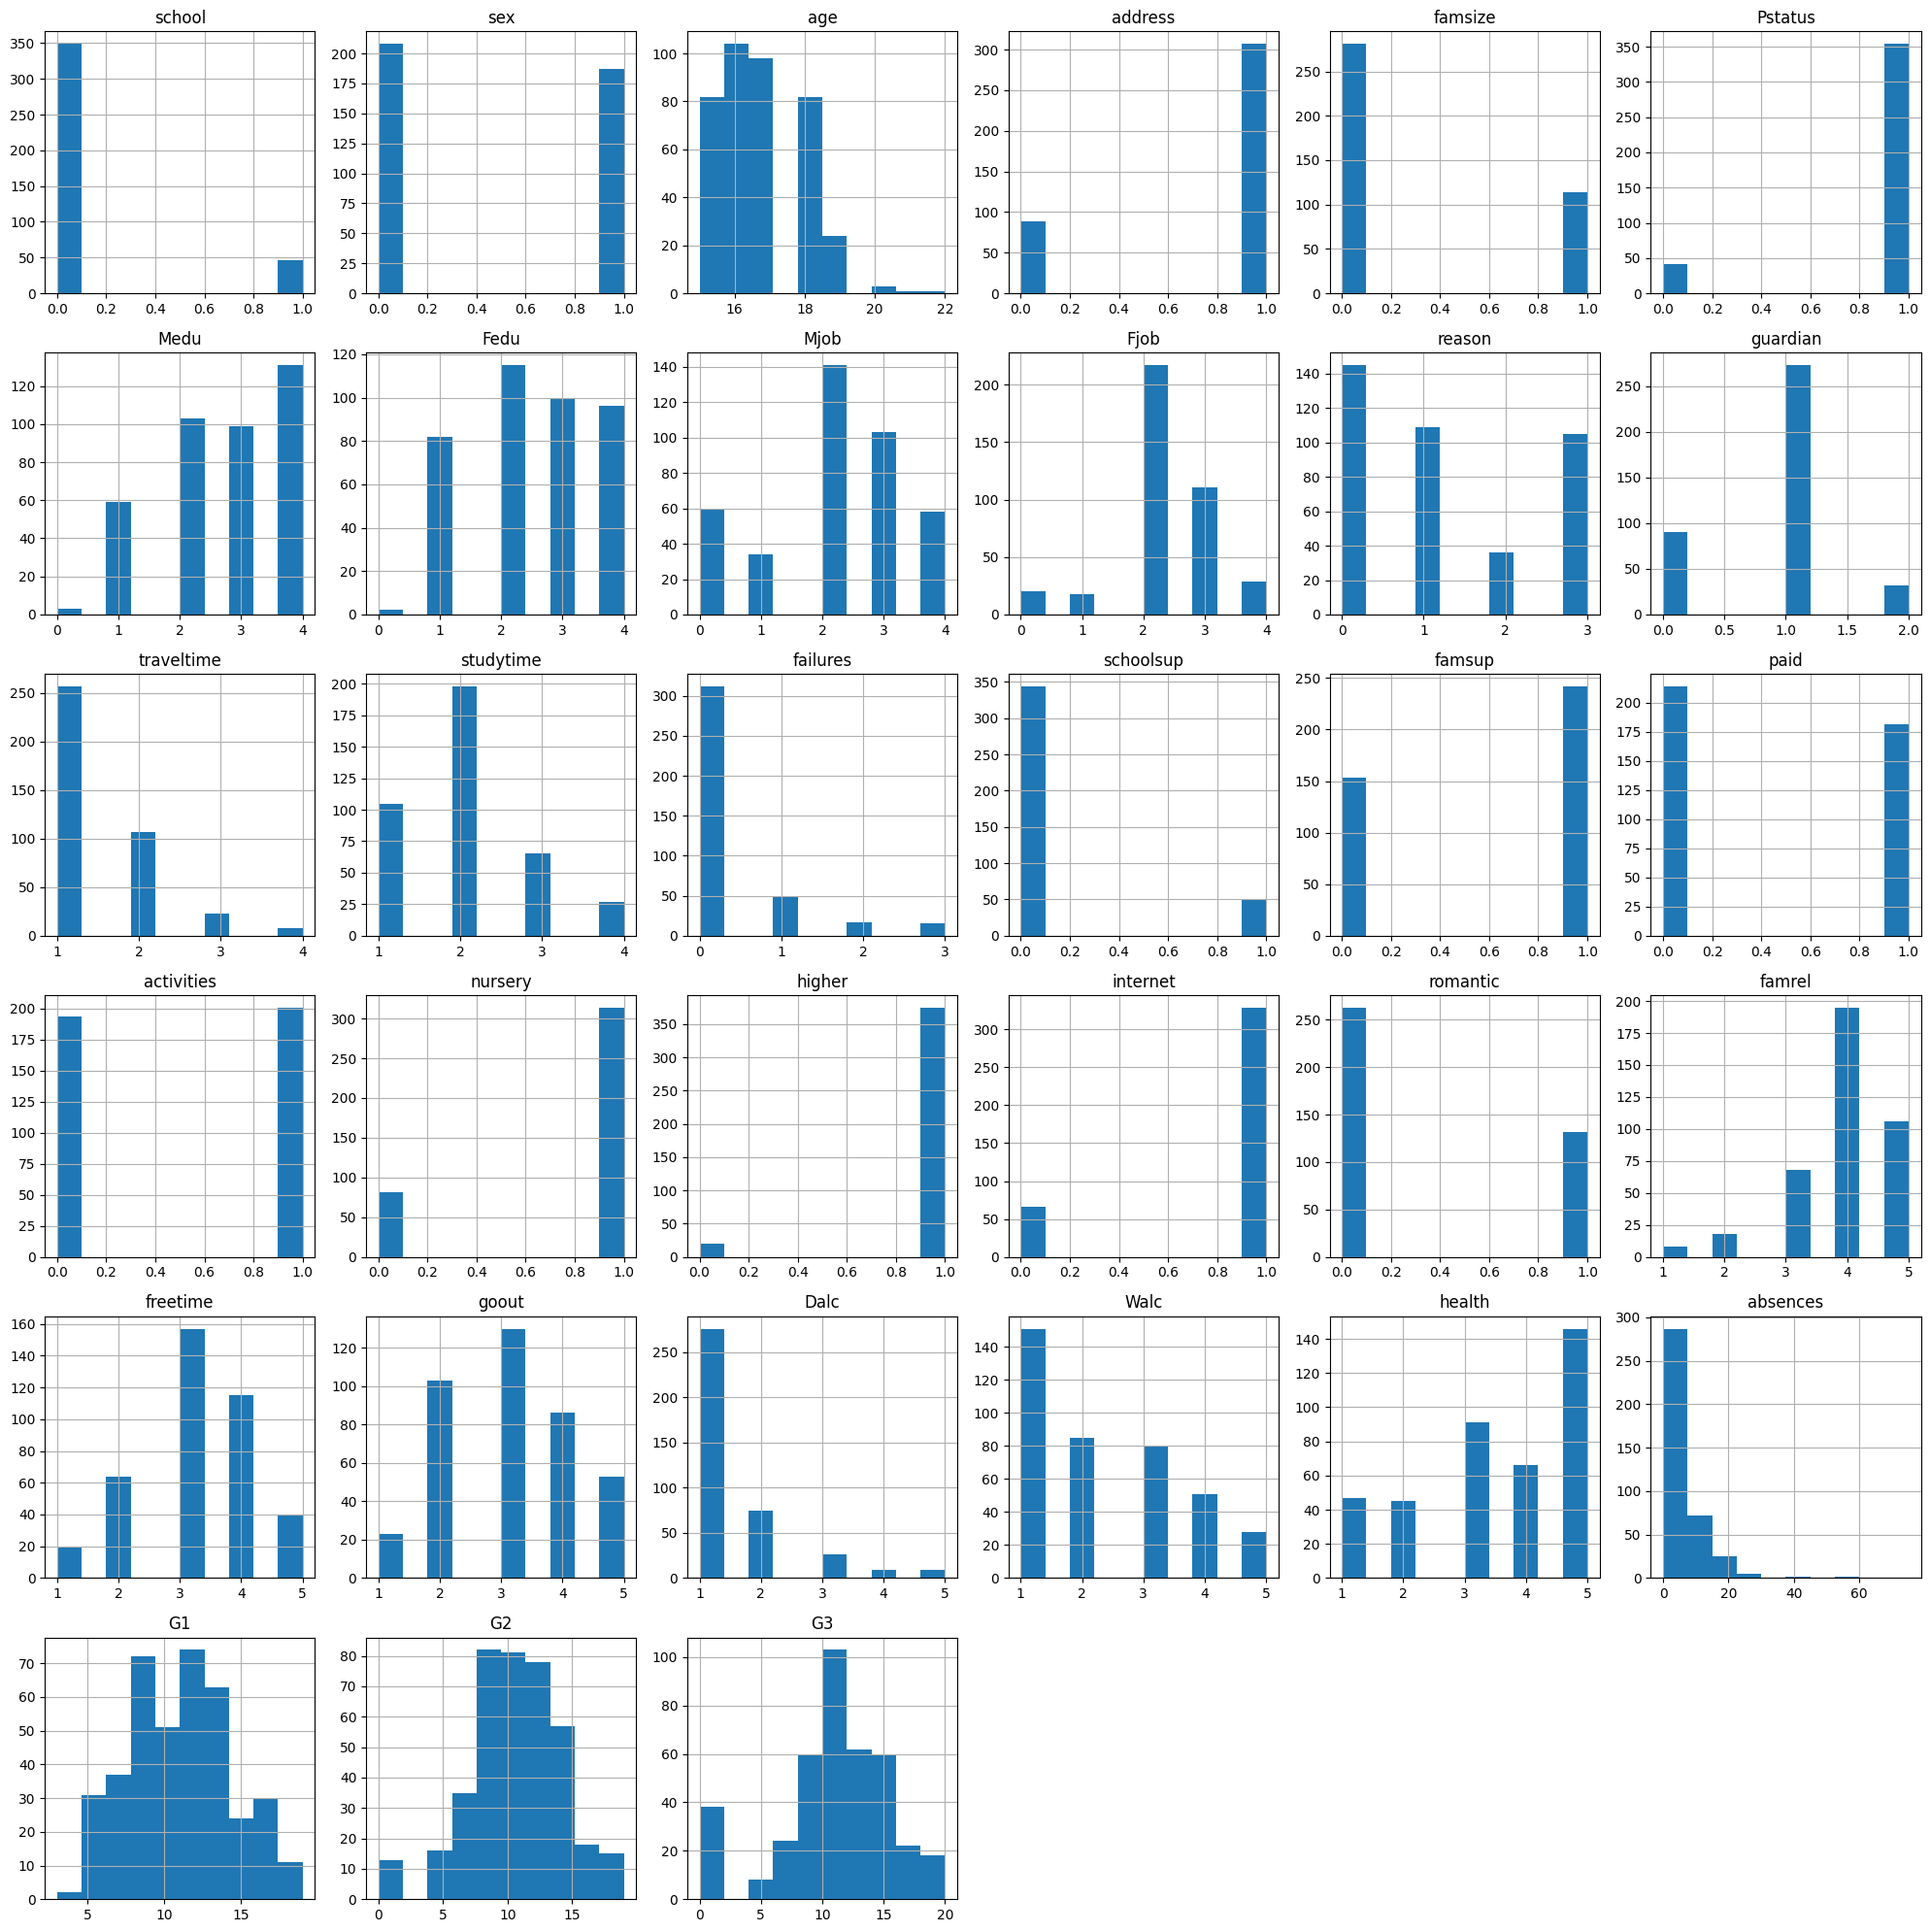

In [ ]:
import matplotlib.pyplot as plt

data.hist(figsize=(20,20))
plt.tight_layout()
plt.show()

In each histogram above, the x-axis represents Feature Values and the y-axis represents represents the Frequencies.

### Split Dataset

In [ ]:
# Drop G3 from X, as this is our target
X = data.drop(['G3'],axis=1)
y = data['G3']

In [ ]:
from sklearn.model_selection import train_test_split

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [ ]:
print("X_train Shape:\n", X_train.shape)
print("\ny_train Shape:\n", y_train.shape)

X_train Shape:
 (296, 32)

y_train Shape:
 (296,)


# Machine Learning Algorithms

### K Nearest Neighbors (Classifier)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Finding best K value
knn_scores = []

for k in range(1, 21):
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_train, y_train)
  score = knn.score(X_test, y_test)
  knn_scores.append(score)

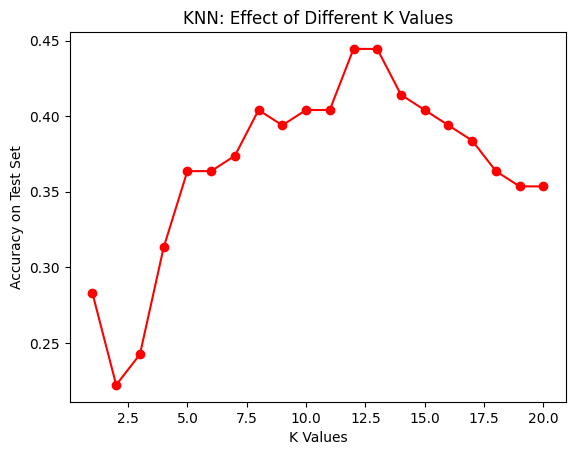

In [ ]:
# Display results graphically
plt.plot(range(1, 21), knn_scores, color='red', marker='o')
plt.xlabel('K Values')
plt.ylabel('Accuracy on Test Set')
plt.title('KNN: Effect of Different K Values')
plt.show()

In [ ]:
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

train_score = knn.score(X_train, y_train)
test_score = knn.score(X_test, y_test)

print("Train Score: {: .2f}".format(train_score))
print("Test Score: {: .2f}".format(test_score))

Train Score:  0.46
Test Score:  0.35


- These Test Set Accuracies are alarmingly low
- As our target G3 is a value between 0-20, it could be 21 different values
- Due to this, this problem may be more suited to Regression than Classification

### K Nearest Neighbours (Regressor)

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

# Finding best K value
knn_scores = []

for k in range(1, 21):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    score = knn.score(X_test, y_test)
    knn_scores.append(score)

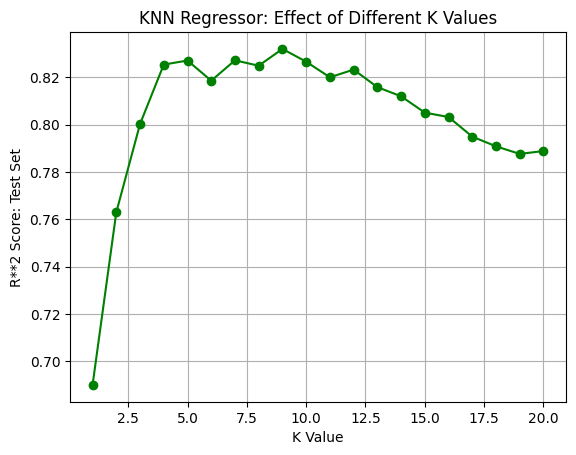

In [ ]:
# Display results graphically
plt.plot(range(1, 21), knn_scores, color='green', marker='o')
plt.xlabel('K Value')
plt.ylabel('R**2 Score: Test Set')
plt.title('KNN Regressor: Effect of Different K Values')
plt.grid(True)
plt.show()

In [ ]:
# Checking different K Values on Train/Test scores
train_scores = []
test_scores = []

for k in range(1, 21):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_scores.append(knn.score(X_train, y_train))
    test_scores.append(knn.score(X_test, y_test))

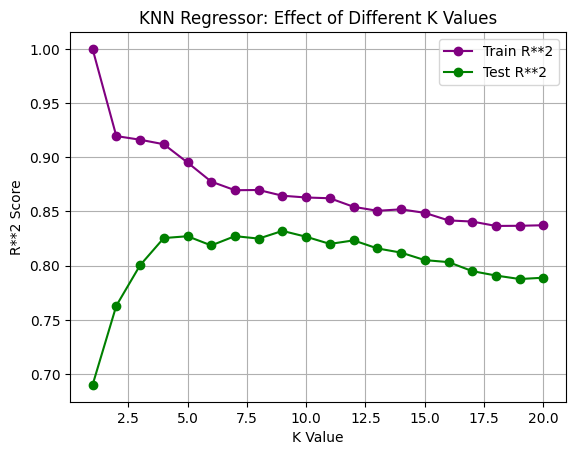

In [ ]:
# Display results graphically
plt.plot(range(1, 21), train_scores, label='Train R**2', color='purple', marker='o')
plt.plot(range(1, 21), test_scores, label='Test R**2', color='green', marker='o')
plt.xlabel('K Value')
plt.ylabel('R**2 Score')
plt.title('KNN Regressor: Effect of Different K Values')
plt.legend()
plt.grid(True)
plt.show()

- 9 looks to be the best value of K

In [ ]:
# Train model with best_k value
best_k = 9
knn = KNeighborsRegressor(n_neighbors=best_k)
knn.fit(X_train, y_train)

r2_train = knn.score(X_train, y_train)
r2_test = knn.score(X_test, y_test)

print("Train R**2 score: {: .2f}".format(r2_train))
print("Test R**2 score: {: .2f}".format(r2_test))

Train R**2 score:  0.86
Test R**2 score:  0.83


K-Nearest Neighbors (Regressor) on Student Grades (Summary):
- Good performance on both training and testing data
- Low variance between these could mean good generalisation of the model


### Decision Tree (Regressor)

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

# Train model
tree = DecisionTreeRegressor(random_state=0)
tree.fit(X_train, y_train)

DecisionTreeRegressor(random_state=0)

In [ ]:
# Test prediction power of tree
r2_train = tree.score(X_train, y_train)
r2_test = tree.score(X_test, y_test)

print("Train R**2 score: {: .2f}".format(r2_train))
print("Test R**2 score: {: .2f}".format(r2_test))

Train R**2 score:  1.00
Test R**2 score:  0.86


- appears to be overfitted, as Train score is perfect
- can prune the tree to improve Test score

In [ ]:
# Find best value for max_depth
max_depth_range = range(2, 11)
train_scores = []
test_scores = []

for depth in max_depth_range:
    tree = DecisionTreeRegressor(max_depth=depth, random_state=0)
    tree.fit(X_train, y_train)
    train_score = tree.score(X_train, y_train)
    train_scores.append(train_score)
    test_score = tree.score(X_test, y_test)
    test_scores.append(test_score)

    print(f"max_depth={depth}:\nR**2 Test: {test_score:.2f}\n")

max_depth=2:
R**2 Test: 0.69

max_depth=3:
R**2 Test: 0.83

max_depth=4:
R**2 Test: 0.84

max_depth=5:
R**2 Test: 0.82

max_depth=6:
R**2 Test: 0.88

max_depth=7:
R**2 Test: 0.87

max_depth=8:
R**2 Test: 0.87

max_depth=9:
R**2 Test: 0.86

max_depth=10:
R**2 Test: 0.85



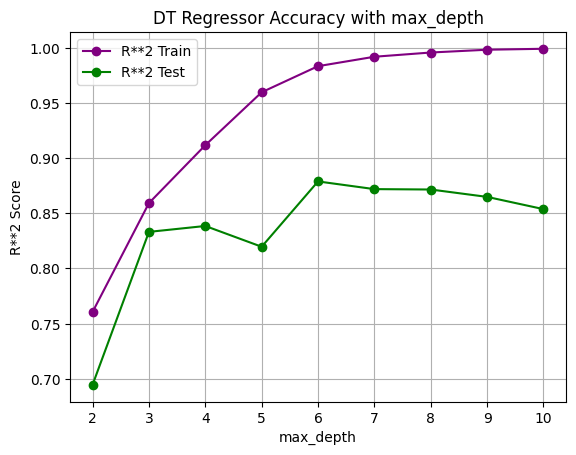

In [ ]:
# Display results graphically
plt.plot(max_depth_range, train_scores, label='R**2 Train', color='purple', marker='o')
plt.plot(max_depth_range, test_scores, label='R**2 Test', color='green', marker='o')
plt.xlabel('max_depth')
plt.ylabel('R**2 Score')
plt.title('DT Regressor Accuracy with max_depth')
plt.legend()
plt.grid(True)
plt.show()

- setting max_depth to 6 is optimal and provides a better test score compared to the unpruned tree

In [ ]:
# Train model with best max_depth
tree = DecisionTreeRegressor(max_depth=6, random_state=0)
tree.fit(X_train, y_train)

r2_train = tree.score(X_train, y_train)
r2_test = tree.score(X_test, y_test)

print("Train R**2 score: {: .2f}".format(r2_train))
print("Test R**2 score: {: .2f}".format(r2_test))

Train R**2 score:  0.98
Test R**2 score:  0.88


Decision Tree (Regressor) on Student Grades (Summary):
- Better test performance than KNN
- Fits and Generalises well to the dataset

### Neural Network (MLPRegressor)

- solver='adam' used instead of solver='lbfgs' for smoother handling of larger datasets

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score

# Train model
mlp = MLPRegressor(hidden_layer_sizes=(100,), activation='relu', solver='adam',
                   max_iter=1000, random_state=0)
mlp.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(max_iter=1000, random_state=0)

In [ ]:
# Predict
r2_train = tree.score(X_train, y_train)
r2_test = tree.score(X_test, y_test)

print("Train R**2 score: {: .2f}".format(r2_train))
print("Test R**2 score: {: .2f}".format(r2_test))

Train R**2 score:  0.98
Test R**2 score:  0.88


- Not bad, can adjust value of Alpha to see if we can improve

In [ ]:
# Find best value for alpha
alphas = [0.0001, 0.001, 0.01, 0.1, 1]
train_scores = []
test_scores = []

for alpha in alphas:
    mlp = MLPRegressor(hidden_layer_sizes=(100,), activation='relu',
                       solver='adam', alpha=alpha,
                       max_iter=1000, random_state=0,
                       early_stopping=True, validation_fraction=0.1)

    mlp.fit(X_train, y_train)
    train_scores.append(mlp.score(X_train, y_train))
    test_scores.append(mlp.score(X_test, y_test))

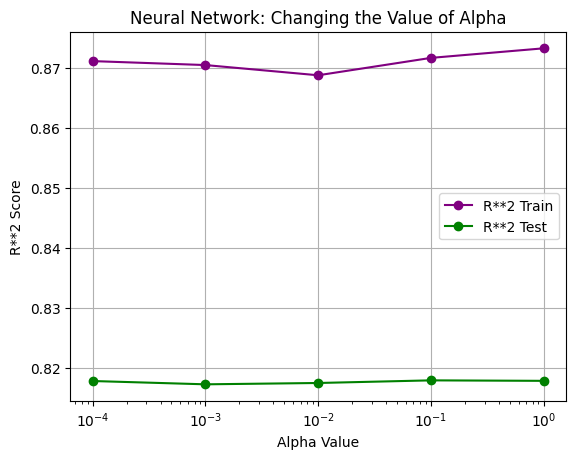

In [ ]:
# Display results graphically
plt.plot(alphas, train_scores, label='R**2 Train', color='purple', marker='o')
plt.plot(alphas, test_scores, label='R**2 Test', color='green', marker='o')
plt.xscale('log')
plt.xlabel('Alpha Value')
plt.ylabel('R**2 Score')
plt.title('Neural Network: Changing the Value of Alpha')
plt.legend()
plt.grid(True)
plt.show()

- Changing the value of Alpha does not seem to improve performance
- We can check to see if changing the hidden_layer_sizes will improve performance

In [ ]:
# Finding best size for hidden_layer_sizes
layer_sizes = [(50,), (100,), (50, 25), (100, 50), (100, 50, 25)]
train_scores = []
test_scores = []

for size in layer_sizes:
    mlp = MLPRegressor(hidden_layer_sizes=size, activation='relu',
                       solver='adam', alpha=0.0001,
                       max_iter=1000, random_state=0,)

    mlp.fit(X_train, y_train)
    train_scores.append(mlp.score(X_train, y_train))
    test_scores.append(mlp.score(X_test, y_test))

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


- Could not display hidden_layer_sizes on the x-axis, so have used a Key below the plot

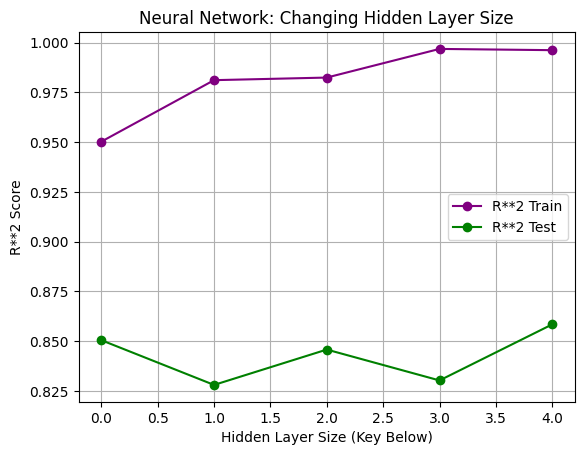

In [ ]:
# Display results graphically
x = range(len(layer_sizes))

plt.plot(x, train_scores, label='R**2 Train', color='purple', marker='o')
plt.plot(x, test_scores, label='R**2 Test', color='green', marker='o')
plt.xlabel('Hidden Layer Size (Key Below)')
plt.ylabel('R**2 Score')
plt.title('Neural Network: Changing Hidden Layer Size')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print("Key:")
i = 0.0
for size in layer_sizes:
  print(f"{i} = {size}")
  i += 1

Key:
0.0 = (50,)
1.0 = (100,)
2.0 = (50, 25)
3.0 = (100, 50)
4.0 = (100, 50, 25)


- (100, 50, 25) looks to be the best value for hidden_layer_sizes

In [ ]:
# Train model using best_hidden_layer_sizes
best_hidden_layer_sizes = (100, 50, 25)

mlp = MLPRegressor(hidden_layer_sizes=best_hidden_layer_sizes,
                   activation='relu', solver='adam',
                   alpha=0.0001, max_iter=1000,
                   random_state=0)

mlp.fit(X_train, y_train)

r2_train = mlp.score(X_train, y_train)
r2_test = mlp.score(X_test, y_test)

print("Train R**2 score: {: .2f}".format(r2_train))
print("Test R**2 score: {: .2f}".format(r2_test))

Train R**2 score:  1.00
Test R**2 score:  0.86


Neural Network (MLPRegressor) on Student Grades (Summary):
- Would appear overfitted, but test score is good
- Adjusting NN for hidden_layer_sizes improved the test score
- Generalizes less than DT, but more than KNN

### Linear Regression (Ordinary Least Squares)

In [ ]:
from sklearn.linear_model import LinearRegression

# Train model
lr = LinearRegression()
lr.fit(X_train, y_train)

r2_train = lr.score(X_train, y_train)
r2_test = lr.score(X_test, y_test)

print("Train R**2 score: {: .2f}".format(r2_train))
print("Test R**2 score: {: .2f}".format(r2_test))

Train R**2 score:  0.86
Test R**2 score:  0.79


In [ ]:
print(f"lr.coef_: {lr.coef_}")
print(f"lr.intercept_: {lr.intercept_}")

lr.coef_: [ 0.4264268   0.19115055 -0.15991559  0.14347342  0.10007279 -0.27955432
  0.22154633 -0.16768186 -0.06814658 -0.04198582  0.04816474 -0.10323747
  0.06201193  0.03895389 -0.15642274  0.60602228  0.10589256  0.1600736
 -0.40860814 -0.19114287 -0.01297468 -0.13620804 -0.32631892  0.16618394
  0.04938934 -0.07171554 -0.19293099  0.22790527  0.09632549  0.05009049
  0.15027248  0.95655577]
lr.intercept_: 0.20040913966438012


In [ ]:
# Coefficients of each feature
for i in range(len(X.columns)):
    print(f"{X.columns[i]}: {lr.coef_[i]:.2f}")

school: 0.43
sex: 0.19
age: -0.16
address: 0.14
famsize: 0.10
Pstatus: -0.28
Medu: 0.22
Fedu: -0.17
Mjob: -0.07
Fjob: -0.04
reason: 0.05
guardian: -0.10
traveltime: 0.06
studytime: 0.04
failures: -0.16
schoolsup: 0.61
famsup: 0.11
paid: 0.16
activities: -0.41
nursery: -0.19
higher: -0.01
internet: -0.14
romantic: -0.33
famrel: 0.17
freetime: 0.05
goout: -0.07
Dalc: -0.19
Walc: 0.23
health: 0.10
absences: 0.05
G1: 0.15
G2: 0.96


Linear Regression (OLS) on Student Grades (Summary):
- Quick to train
- Not as generalisable as DT and MLP, but better than KNN

The dataset mentions that G1 and G2 have a strong correlation with G3, so we can experiment by dropping them

In [ ]:
X_reduced = X.drop(['G1', 'G2'], axis=1)

# Split amended data
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reduced, y, random_state=0)

# Train model on amended data
lr_reduced = LinearRegression()
lr_reduced.fit(Xr_train, yr_train)

r2_train_reduced = lr_reduced.score(Xr_train, yr_train)
r2_test_reduced = lr_reduced.score(Xr_test, yr_test)

print("Train R**2 score: {: .2f}".format(r2_train_reduced))
print("Test R**2 score: {: .2f}".format(r2_test_reduced))

Train R**2 score:  0.26
Test R**2 score:  0.13


Linear Regression (OLS) with G1 and G2 dropped Summary:
- Sharp drop on both Train and Test scores
- Confirms that other Features have less influence on G3 for OLS